# 🌾 Pest Early Warning System — Unsupervised Autoencoder
### CSIR-CSIO | Sajal Goel | SID: 23106031 | Internship 2026
---
**Method:** Conv3D + ConvLSTM Autoencoder learns *normal* pest patterns across districts.  
When reconstruction error exceeds the **Shewhart threshold (μ + 1.96σ)**, an outbreak alert is raised.

**Run cells in order: Cell 0 → Cell 1 → ... → Cell 16**

## Cell 0 — Setup *(run this first)*

In [1]:
import zipfile, os

# Extract unsupervised_v2 modules
if os.path.exists("unsupervised_v2.zip") and not os.path.isdir("unsupervised_v2"):
    with zipfile.ZipFile("unsupervised_v2.zip") as z:
        z.extractall(".")
    print("Extracted unsupervised_v2/ ✓")
else:
    print("unsupervised_v2/ already present ✓")

Extracted unsupervised_v2/ ✓


In [2]:
import sys, os, types

print("Working dir:", os.getcwd())

MODULE_DIR = os.path.join(os.getcwd(), "unsupervised_v2")
assert os.path.isdir(MODULE_DIR), f"Folder not found: {MODULE_DIR}"
if MODULE_DIR not in sys.path:
    sys.path.insert(0, MODULE_DIR)

def load_patched(name, filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        src = f.read()
    src = src.replace("from .config import",       "from config import")
    src = src.replace("from .model import",         "from model import")
    src = src.replace("from .data_pipeline import", "from data_pipeline import")
    mod = types.ModuleType(name)
    mod.__file__ = filepath
    exec(compile(src, filepath, "exec"), mod.__dict__)
    sys.modules[name] = mod
    return mod

load_patched("config",        os.path.join(MODULE_DIR, "config.py"))
load_patched("model",         os.path.join(MODULE_DIR, "model.py"))
load_patched("data_pipeline", os.path.join(MODULE_DIR, "data_pipeline.py"))
load_patched("train",         os.path.join(MODULE_DIR, "train.py"))
load_patched("evaluation",    os.path.join(MODULE_DIR, "evaluation.py"))

print("All 5 modules loaded successfully ✓")

Working dir: /content
All 5 modules loaded successfully ✓


## Cell 1 — Imports

In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa", "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3,
})
ALERT_COLORS = {"RED":"#e74c3c","ORANGE":"#e67e22","YELLOW":"#f1c40f","GREEN":"#2ecc71"}

from config import ExperimentConfig, DataConfig, ModelConfig
from data_pipeline import (
    audit_data, aggregate_pest_counts, pivot_to_wide, fill_implicit_zeros,
    create_complete_grid, impute_harvest_area, impute_rainfall,
    drop_missing_coordinates, run_feature_engineering, split_by_year,
    verify_complete_cycles, compute_haversine_matrix, get_knn_neighbors,
    fit_scaler, apply_scaler, create_dataloaders,
)
from model import build_model_from_config
from train import train_model
from evaluation import (
    compute_reconstruction_errors, compute_per_pest_scores,
    compute_thresholds, flag_outbreaks, get_first_detection_dates,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 50)
print("  PEST EWS — Unsupervised Autoencoder")
print("  CSIR-CSIO | Sajal Goel | 2026")
print("=" * 50)
print(f"  Torch  : {torch.__version__}")
print(f"  Device : {device}")
print("  All imports OK ✓")

  PEST EWS — Unsupervised Autoencoder
  CSIR-CSIO | Sajal Goel | 2026
  Torch  : 2.11.0+cu128
  Device : cuda
  All imports OK ✓


## Cell 2 — Configuration *(only edit this cell)*

In [4]:
CSV_PATH = "merged_output.csv"

config = ExperimentConfig()

# ── DataConfig ────────────────────────────────────────────────────────────────
config.data.date_column         = "createdon"
config.data.district_column     = "district"
config.data.state_column        = "state"
config.data.pest_column         = "pest"
config.data.count_column        = "pest_count"
config.data.latitude_column     = "latitude"
config.data.longitude_column    = "longitude"
config.data.rainfall_column     = "rainfall"
config.data.harvest_area_column = "harvest_area"
config.data.crop_column         = "crop"

# ── ModelConfig ───────────────────────────────────────────────────────────────
config.model.window_size   = 6
config.model.step_size     = 1
config.model.num_neighbors = 5
config.model.epochs        = 100
config.model.batch_size    = 16
config.model.learning_rate = 1e-4
config.model.patience      = 15
config.model.log_every     = 5

# ── Year splits ───────────────────────────────────────────────────────────────
config.train_years           = [2013, 2014, 2015]
config.val_years             = [2016]
config.test_years            = [2017]
config.threshold_p           = 0.95    # Shewhart: μ + 1.96σ
config.outlier_percentile    = 99.0
config.crop_aware_neighbors  = False

print("Config ready:")
print(f"  window={config.model.window_size}  neighbours={config.model.num_neighbors}")
print(f"  train={config.train_years}  val={config.val_years}  test={config.test_years}")
print(f"  epochs={config.model.epochs}  lr={config.model.learning_rate}  batch={config.model.batch_size}")
print(f"  threshold_p={config.threshold_p}  (Shewhart z ≈ 1.96)")

Config ready:
  window=6  neighbours=5
  train=[2013, 2014, 2015]  val=[2016]  test=[2017]
  epochs=100  lr=0.0001  batch=16
  threshold_p=0.95  (Shewhart z ≈ 1.96)


## Cell 3 — Load & Validate Data

In [5]:
print("[Step 0] Loading CSV ...")
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip().str.lower()
print(f"  Shape   : {df.shape}")
print(f"  Columns : {list(df.columns)}")

# ── IMPORTANT: Validate this is the full dataset ──────────────────────────────
# Colab loses uploaded files on disconnect — you may be running on a stale/partial CSV
MIN_ROWS      = 400_000   # full merged_output.csv has ~460,899 rows
MIN_DISTRICTS = 500       # full dataset has 543 districts

n_rows = len(df)
n_dist = df["district"].nunique() if "district" in df.columns else 0

if n_rows < MIN_ROWS:
    print(f"\n⚠️  WARNING: Only {n_rows:,} rows found (expected ≥ {MIN_ROWS:,})")
    print("   Your Colab session may be using a partial/filtered CSV.")
    print("   Re-upload the full merged_output.csv and re-run from Cell 3.")
    print("   Continuing anyway — results will cover fewer districts.\n")
else:
    print(f"\n✅ Dataset validated: {n_rows:,} rows, {n_dist} districts ✓")

# ── Auto-detect column names ───────────────────────────────────────────────────
def find(candidates, cols):
    for c in candidates:
        if c in cols: return c
    return None

actual       = list(df.columns)
district_col = find(["district","dist_name","dist name"], actual)
state_col    = find(["state","state_name","state name"],  actual)
pest_col     = find(["pest"],                             actual)
count_col    = find(["pest_count","count"],               actual)
date_col     = find(["createdon","created_on","date"],    actual)
lat_col      = find(["latitude","lat","lattitude"],       actual)
lon_col      = find(["longitude","lon"],                  actual)

assert district_col, "❌ district column not found!"
assert pest_col,     "❌ pest column not found!"
assert count_col,    "❌ count column not found!"
assert date_col,     "❌ date column not found!"

config.data.district_column  = district_col
config.data.state_column     = state_col or district_col
config.data.pest_column      = pest_col
config.data.count_column     = count_col
config.data.date_column      = date_col
config.data.latitude_column  = lat_col
config.data.longitude_column = lon_col

print(f"  district={district_col}  pest={pest_col}  count={count_col}")
print(f"  date={date_col}  lat={lat_col}  lon={lon_col}")

# ── Add placeholder columns if absent ────────────────────────────────────────
for col, val, attr in [
    ("rainfall",     0.0,       "rainfall_column"),
    ("harvest_area", 1000.0,    "harvest_area_column"),
    ("crop",         "UNKNOWN", "crop_column"),
    ("state",        "UNKNOWN", "state_column"),
]:
    if col not in df.columns:
        df[col] = val
        setattr(config.data, attr, col)
        print(f"  Added placeholder: {col}")

df[config.data.date_column] = pd.to_datetime(df[config.data.date_column], errors="coerce")
df.dropna(subset=[config.data.date_column], inplace=True)

print(f"\n  Date range : {df[config.data.date_column].min().date()} → {df[config.data.date_column].max().date()}")
print(f"  Districts  : {df[config.data.district_column].nunique()}")
print(f"  Pests      : {df[config.data.pest_column].nunique()}")
print(f"  Rows       : {len(df):,}")

[Step 0] Loading CSV ...
  Shape   : (460899, 6)
  Columns : ['district', 'pest', 'createdon', 'pest_count', 'latitude', 'longitude']

✅ Dataset validated: 460,899 rows, 543 districts ✓
  district=district  pest=pest  count=pest_count
  date=createdon  lat=latitude  lon=longitude
  Added placeholder: rainfall
  Added placeholder: harvest_area
  Added placeholder: crop
  Added placeholder: state

  Date range : 2013-01-01 → 2017-09-26
  Districts  : 543
  Pests      : 63
  Rows       : 460,899


In [6]:
import pandas as pd
df_check = pd.read_csv("merged_output.csv")
print(len(df_check), df_check["district"].nunique())
# Should print: 460899  543
# If it prints: 125408  139  → wrong file, re-upload

460899 543


## Cell 4 — Phases 1–3: Audit, Reshape, Impute

In [7]:
# Phase 1
print("[Phase 1] Auditing ...")
audit = audit_data(df, config.data)
print(f"  Pests     : {len(audit['unique_pests'])}")
print(f"  Districts : {len(audit['unique_districts'])}")

# Phase 2
print("\n[Phase 2] Long → Wide ...")
aggregated         = aggregate_pest_counts(df, config.data)
wide, pest_columns = pivot_to_wide(aggregated, config.data)
wide               = fill_implicit_zeros(wide, pest_columns)
wide               = create_complete_grid(wide, pest_columns, config.data)
print(f"  Wide shape   : {wide.shape}")
print(f"  Pest columns : {len(pest_columns)}")

# Phase 3 — Impute ALL NaNs before feature engineering
print("\n[Phase 3] Imputing ...")
wide = impute_harvest_area(wide, config.data)
wide = impute_rainfall(wide, config.data)
wide = drop_missing_coordinates(wide, config.data)

if "rainfall" in wide.columns: wide["rainfall"]     = wide["rainfall"].fillna(0.0)
if "crop"     in wide.columns: wide["crop"]         = wide["crop"].fillna("UNKNOWN")
num_cols = wide.select_dtypes(include=[np.number]).columns
wide[num_cols] = wide[num_cols].fillna(0)
cat_cols = wide.select_dtypes(exclude=[np.number]).columns
wide[cat_cols] = wide[cat_cols].fillna("UNKNOWN")
if "crop" in wide.columns: wide = wide.drop(columns=["crop"])

print(f"  Districts after coord filter : {wide[config.data.district_column].nunique()}")
print(f"  NaNs remaining               : {wide.isna().sum().sum()} ✓")

[Phase 1] Auditing ...
  Pests     : 63
  Districts : 543

[Phase 2] Long → Wide ...
  Wide shape   : (30951, 71)
  Pest columns : 63

[Phase 3] Imputing ...
  Districts after coord filter : 543
  NaNs remaining               : 0 ✓


## Cell 5 — Phases 4–5: Feature Engineering & Year Split

In [8]:
# Phase 4
print("[Phase 4] Feature engineering ...")
wide, feature_cols = run_feature_engineering(wide, pest_columns, config)
print(f"  Feature columns : {len(feature_cols)}")

# Phase 5 — filter ALL splits by same valid_districts set
print("\n[Phase 5] Year split ...")
train_df, val_df, test_df = split_by_year(wide, config)
valid_districts = verify_complete_cycles(train_df, pest_columns, config.data)

train_df = train_df[train_df[config.data.district_column].isin(valid_districts)].reset_index(drop=True)
val_df   = val_df  [val_df  [config.data.district_column].isin(valid_districts)].reset_index(drop=True)
test_df  = test_df [test_df [config.data.district_column].isin(valid_districts)].reset_index(drop=True)

print(f"  Train : {len(train_df):,} rows  ({config.train_years})")
print(f"  Val   : {len(val_df):,} rows   ({config.val_years})")
print(f"  Test  : {len(test_df):,} rows   ({config.test_years})")
print(f"  Valid districts (all splits) : {len(valid_districts)}")

[Phase 4] Feature engineering ...


  Feature columns : 254

[Phase 5] Year split ...
  Train : 19,512 rows  ([2013, 2014, 2015])
  Val   : 6,504 rows   ([2016])
  Test  : 4,878 rows   ([2017])
  Valid districts (all splits) : 542


## Cell 6 — Phase 6: Haversine Graph

In [9]:
print("[Phase 6] Building Haversine distance matrix & KNN graph ...")
dist_matrix, district_names = compute_haversine_matrix(wide, config.data)
neighbors = get_knn_neighbors(
    dist_matrix, district_names,
    m=config.model.num_neighbors,
    crop_aware=config.crop_aware_neighbors,
)
print(f"  Districts in graph  : {len(district_names)}")
print(f"  Neighbours per node : {config.model.num_neighbors}")

[Phase 6] Building Haversine distance matrix & KNN graph ...
  Districts in graph  : 543
  Neighbours per node : 5


## Cell 7 — Phase 7: Sliding Window Tensors *(fast vectorised)*
Replaces the original `build_subsequences` which takes 60+ minutes with a numpy vectorised version (~1 min).

In [10]:
import numpy as np

T        = config.model.window_size
s        = config.model.step_size
m        = config.model.num_neighbors
d        = len(feature_cols)
dist_col = config.data.district_column
# run_feature_engineering renames the date col to "date" internally
date_col = "date" if "date" in train_df.columns else config.data.date_column

target_cols = []
for pcol in pest_columns:
    for suffix in ["", "_delta", "_cumulative"]:
        cname = f"{pcol}{suffix}"
        if cname in feature_cols:
            target_cols.append(cname)
d_pest         = len(target_cols)
target_indices = np.array([feature_cols.index(c) for c in target_cols])

def build_district_arrays(df, dist_col, date_col, feature_cols):
    arrays = {}
    for district, grp in df.groupby(dist_col, sort=False):
        grp   = grp.sort_values(date_col)
        dates = grp[date_col].values
        feats = grp[feature_cols].values.astype(np.float32)
        arrays[district] = (dates, feats)
    return arrays

def fast_build(df, feature_cols, target_indices, neighbors,
               T, s, m, d, d_pest, dist_col, date_col):
    arrays    = build_district_arrays(df, dist_col, date_col, feature_cols)
    all_in, all_tgt, all_meta = [], [], []
    dist_list = [d_ for d_ in neighbors if d_ in arrays]
    total     = len(dist_list)

    for idx, district in enumerate(dist_list):
        if idx % 50 == 0:
            print(f"    {idx}/{total} districts ...", end="\r")
        dates, feats = arrays[district]
        L = len(dates)
        if L < T: continue
        starts      = np.arange(0, L - T + 1, s)
        N           = len(starts)
        if N == 0: continue
        idx_grid    = starts[:, None] + np.arange(T)[None, :]
        target_wins = feats[idx_grid]
        tensor      = np.zeros((N, T, d, m), dtype=np.float32)
        tensor[:, :, :, 0] = target_wins
        nbrs = neighbors[district][:m - 1]
        for k, nb in enumerate(nbrs):
            if nb not in arrays: continue
            nb_dates, nb_feats = arrays[nb]
            if len(nb_dates) < T: continue
            for wi, st in enumerate(starts):
                w0 = dates[st]; w1 = dates[st + T - 1]
                i0 = np.searchsorted(nb_dates, w0)
                i1 = np.searchsorted(nb_dates, w1, side="right")
                nb_win = nb_feats[i0:i1]
                if len(nb_win) == T:
                    tensor[wi, :, :, k + 1] = nb_win
                elif len(nb_win) > 0:
                    fl = min(len(nb_win), T)
                    tensor[wi, :fl, :, k + 1] = nb_win[:fl]
        tgt  = target_wins[:, :, target_indices]
        meta = [{"district": district,
                 "start_date": str(dates[st]),
                 "end_date":   str(dates[st + T - 1])} for st in starts]
        all_in.append(tensor); all_tgt.append(tgt); all_meta.extend(meta)

    print(f"    {total}/{total} districts done.      ")
    inputs  = np.concatenate(all_in,  axis=0) if all_in  else np.zeros((0,T,d,m),    dtype=np.float32)
    targets = np.concatenate(all_tgt, axis=0) if all_tgt else np.zeros((0,T,d_pest), dtype=np.float32)
    return inputs, targets, all_meta

print("[Phase 7] Building train tensors ...")
train_inputs, train_targets, train_meta = fast_build(
    train_df, feature_cols, target_indices, neighbors, T, s, m, d, d_pest, dist_col, date_col)
print("[Phase 7] Building val tensors ...")
val_inputs, val_targets, val_meta = fast_build(
    val_df, feature_cols, target_indices, neighbors, T, s, m, d, d_pest, dist_col, date_col)
print("[Phase 7] Building test tensors ...")
test_inputs, test_targets, test_meta = fast_build(
    test_df, feature_cols, target_indices, neighbors, T, s, m, d, d_pest, dist_col, date_col)

print(f"\n  Train : inputs {train_inputs.shape}  targets {train_targets.shape}")
print(f"  Val   : inputs {val_inputs.shape}  targets {val_targets.shape}")
print(f"  Test  : inputs {test_inputs.shape}  targets {test_targets.shape}")

[Phase 7] Building train tensors ...
    542/542 districts done.      
[Phase 7] Building val tensors ...
    542/542 districts done.      
[Phase 7] Building test tensors ...
    542/542 districts done.      

  Train : inputs (16802, 6, 254, 5)  targets (16802, 6, 189)
  Val   : inputs (3794, 6, 254, 5)  targets (3794, 6, 189)
  Test  : inputs (2168, 6, 254, 5)  targets (2168, 6, 189)


## Cell 8 — Phase 8: Normalise + DataLoaders

In [11]:
print("[Phase 8] RobustScaler normalisation ...")
scaler, cap_value = fit_scaler(train_inputs, outlier_percentile=config.outlier_percentile)
train_inputs = apply_scaler(train_inputs, scaler, cap_value)
if val_inputs.shape[0]  > 0: val_inputs  = apply_scaler(val_inputs,  scaler, cap_value)
if test_inputs.shape[0] > 0: test_inputs = apply_scaler(test_inputs, scaler, cap_value)
print(f"  Cap value : {cap_value:.4f}")

train_loader, val_loader, test_loader = create_dataloaders(
    train_inputs, train_targets,
    val_inputs,   val_targets,
    test_inputs,  test_targets,
    batch_size=config.model.batch_size,
)
print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")

[Phase 8] RobustScaler normalisation ...
  Cap value : 14.0000
  Train batches : 1051
  Val batches   : 238
  Test batches  : 136


## Cell 9 — Phase 9: Build & Train Autoencoder

In [12]:
num_total_features = train_inputs.shape[2]
num_pest_features  = train_targets.shape[2]

print("[Phase 9] Building model ...")
print(f"  Input features  (d)      : {num_total_features}")
print(f"  Target features (d_pest) : {num_pest_features}")
print(f"  Time steps      (T)      : {train_inputs.shape[1]}")
print(f"  Spatial layers  (m)      : {train_inputs.shape[3]}")

model = build_model_from_config(
    num_features      = num_total_features,
    num_pest_features = num_pest_features,
    config            = config,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"  Model params : {n_params:,}")
print(f"  Architecture : Conv3DEncoder → ConvLSTMEncoder → Decoder")
print(f"\nTraining up to {config.model.epochs} epochs (patience={config.model.patience}) ...")

model, history = train_model(
    model          = model,
    train_loader   = train_loader,
    val_loader     = val_loader,
    config         = config,
    device         = device,
    checkpoint_dir = "./ews_checkpoints",
)
print(f"\n  Best epoch    : {history['best_epoch']}")
print(f"  Best val loss : {history['best_val_loss']:.6f}")

[Phase 9] Building model ...
  Input features  (d)      : 254
  Target features (d_pest) : 189
  Time steps      (T)      : 6
  Spatial layers  (m)      : 5
  Model params : 1,112,719
  Architecture : Conv3DEncoder → ConvLSTMEncoder → Decoder

Training up to 100 epochs (patience=15) ...

  Best epoch    : 82
  Best val loss : 0.701421


## Cell 10 — Training Curves

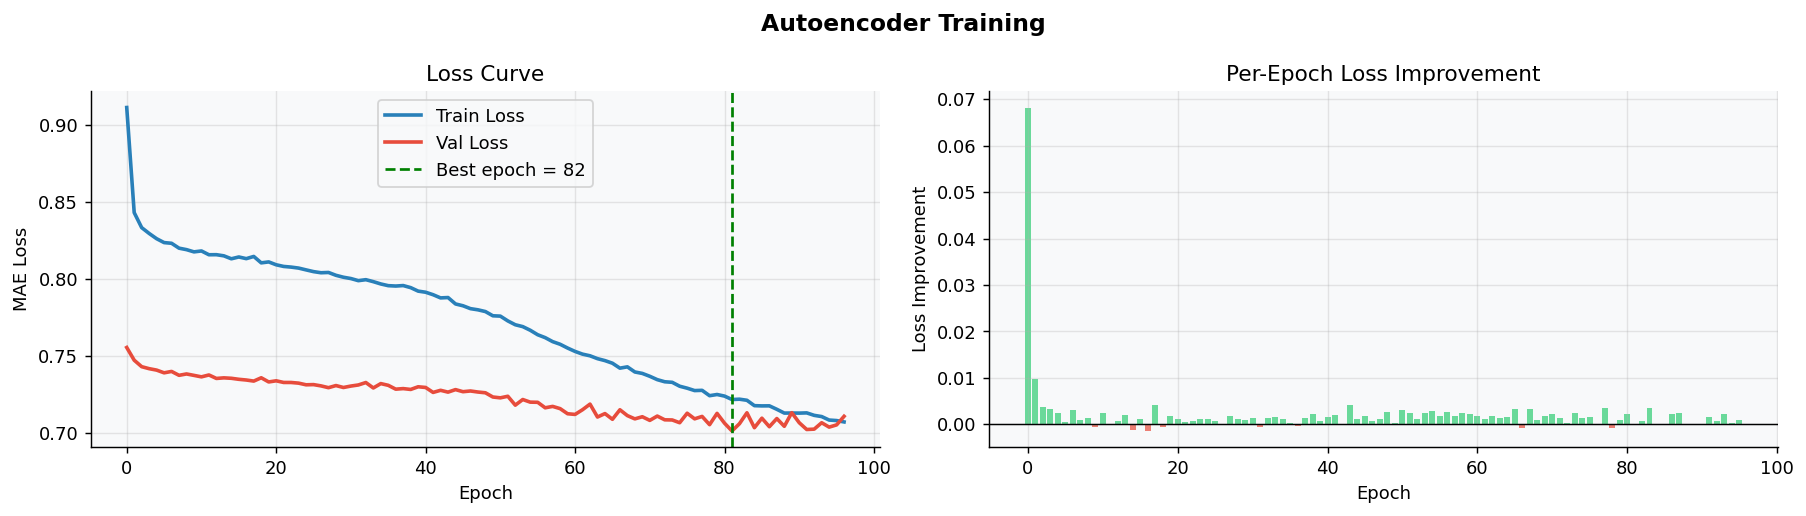

Saved: ews_ae_01_training.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Autoencoder Training", fontsize=13, fontweight="bold")

axes[0].plot(history["train_losses"], color="#2980b9", lw=2, label="Train Loss")
axes[0].plot(history["val_losses"],   color="#e74c3c", lw=2, label="Val Loss")
axes[0].axvline(history["best_epoch"]-1, color="green", lw=1.5, linestyle="--",
                label=f"Best epoch = {history['best_epoch']}")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MAE Loss")
axes[0].set_title("Loss Curve"); axes[0].legend()

train_l = np.array(history["train_losses"])
delta   = np.diff(train_l)
axes[1].bar(range(len(delta)), -delta,
            color=["#2ecc71" if x < 0 else "#e74c3c" for x in delta], alpha=0.7)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss Improvement")
axes[1].set_title("Per-Epoch Loss Improvement")

plt.tight_layout()
plt.savefig("ews_ae_01_training.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ews_ae_01_training.png")

## Cell 11 — Shewhart Thresholds
`threshold = μ + σ × z(1−p/2)`  with p=0.95 → z ≈ 1.96

In [14]:
print("[Phase 10] Computing Shewhart thresholds from training data ...")

train_errors = compute_reconstruction_errors(model, train_loader, device)
pest_names   = list(pest_columns)
train_scores = compute_per_pest_scores(train_errors, pest_names, features_per_pest=3)
thresholds   = compute_thresholds(train_scores, p=config.threshold_p)

thresh_df = pd.DataFrame({
    "pest"      : list(thresholds.keys()),
    "threshold" : list(thresholds.values()),
    "train_mean": [train_scores[p].mean() for p in thresholds],
    "train_std" : [train_scores[p].std()  for p in thresholds],
}).sort_values("threshold", ascending=False).reset_index(drop=True)

print(f"  Thresholds computed for {len(thresholds)} pests")
print(f"  Shewhart p={config.threshold_p}  →  z ≈ 1.96")
print("\n  Top 10 highest thresholds:")
print(thresh_df.head(10).to_string(index=False))

[Phase 10] Computing Shewhart thresholds from training data ...
  Thresholds computed for 63 pests
  Shewhart p=0.95  →  z ≈ 1.96

  Top 10 highest thresholds:
                 pest  threshold  train_mean  train_std
          pest_insect   6.156148    5.454400  11.190945
     pest_caterpiller   5.390119    4.697804  11.040516
        pest_whitefly   5.225176    4.308712  14.615069
           pest_thrip   4.864038    4.165415  11.141110
       pest_stemborer   4.224335    3.721782   8.014333
pest_fruit&shootborer   4.185846    3.775732   6.540177
           pest_aphid   3.905134    3.428106   7.607282
      pest_leaffolder   2.834311    2.289597   8.686682
         pest_termite   2.491906    2.171334   5.112246
        pest_mealybug   1.105336    0.934809   2.719431


## Cell 12 — Test Inference & Outbreak Flagging

In [15]:
print("[Phase 10] Running inference on test data ...")

test_errors  = compute_reconstruction_errors(model, test_loader, device)
test_scores  = compute_per_pest_scores(test_errors, pest_names, features_per_pest=3)
alerts_df    = flag_outbreaks(test_scores, thresholds, metadata=test_meta)

active = alerts_df[alerts_df["flagged"]].copy()

# Alert levels — calibrated thresholds
# ratio >= 5 → RED    (extreme anomaly: confirmed outbreak)
# ratio >= 2 → ORANGE (significant anomaly: high risk)
# ratio >= 1 → YELLOW (mild anomaly: watch zone)
def alert_level(row):
    r = row["score"] / max(row["threshold"], 1e-9)
    if r >= 5.0: return "RED"
    if r >= 2.0: return "ORANGE"
    return "YELLOW"

active["alert_level"] = active.apply(alert_level, axis=1)
active["score_ratio"] = (active["score"] / active["threshold"].replace(0, 1e-9)).round(3)

alerts_df["alert_level"] = alerts_df.apply(
    lambda r: alert_level(r) if r["flagged"] else "GREEN", axis=1)
alerts_df["score_ratio"] = (
    alerts_df["score"] / alerts_df["threshold"].replace(0, 1e-9)).round(3)

print(f"  Total test samples : {len(alerts_df):,}")
print(f"  Active warnings    : {len(active):,}  ({len(active)/len(alerts_df)*100:.1f}%)")
ac = active["alert_level"].value_counts()
for lvl in ["RED","ORANGE","YELLOW"]:
    print(f"    {lvl:7s}: {ac.get(lvl,0):5d}")

print("\n  Top 15 active warnings:")
print(
    active.sort_values("score_ratio", ascending=False)
    [["district","pest","score","threshold","score_ratio","alert_level","start_date"]]
    .head(15).to_string(index=False)
)

[Phase 10] Running inference on test data ...
  Total test samples : 136,584
  Active warnings    : 14,378  (10.5%)
    RED    :  3115
    ORANGE :  4760
    YELLOW :  6503

  Top 15 active warnings:
       district                      pest    score  threshold  score_ratio alert_level                    start_date
        VELLORE          pest_muranaimite 2.168479   0.018237      118.906         RED 2017-01-01T00:00:00.000000000
    VILLUPPURAM              pest_earworm 1.004239   0.010110       99.329         RED 2017-04-01T00:00:00.000000000
    VILLUPPURAM              pest_earworm 0.949173   0.010110       93.883         RED 2017-03-01T00:00:00.000000000
        BARPETA            pest_squashbug 0.334106   0.003570       93.588         RED 2017-01-01T00:00:00.000000000
    VILLUPPURAM              pest_earworm 0.896307   0.010110       88.654         RED 2017-02-01T00:00:00.000000000
       ADILABAD         pest_beanpodborer 0.611229   0.006984       87.522         RED 2017-04-01T

## Cell 13 — Lead-Time Analysis
How many months **before** a confirmed outbreak does the system raise a warning?
This is the primary metric for evaluating any Early Warning System.

In [16]:
print("[Lead-Time] Computing early detection metrics ...")

# Ground truth: monthly pest counts from raw data
gt = (df.assign(month=df[config.data.date_column].dt.to_period("M"))
        .groupby([config.data.district_column, config.data.pest_column, "month"])
        [config.data.count_column].sum()
        .reset_index())
gt.columns = ["district", "pest", "month", "actual_count"]
gt["pest"] = "pest_" + gt["pest"].str.strip().str.lower().str.replace(" ", "_")

# Mark outbreak months: count > 75th percentile for that district-pest pair
p75 = gt.groupby(["district","pest"])["actual_count"].quantile(0.75).rename("p75").reset_index()
gt  = gt.merge(p75, on=["district","pest"])
gt["outbreak"] = gt["actual_count"] > gt["p75"]

# Parse alert start_date to period
alerts_df["month"] = pd.to_datetime(
    alerts_df["start_date"].str[:10], errors="coerce").dt.to_period("M")

merged = alerts_df.merge(gt, on=["district","pest","month"], how="left")
merged["outbreak"] = merged["outbreak"].fillna(False)

# Compute lead time: months between flag and next outbreak
lead_times = []
for (dist, pest), grp in merged.groupby(["district","pest"]):
    grp = grp.sort_values("month")
    outbreak_months = grp[grp["outbreak"]]["month"].tolist()
    flagged_months  = grp[grp["flagged"]]["month"].tolist()
    for fm in flagged_months:
        future = [o for o in outbreak_months if o > fm]
        if future:
            lead = (future[0] - fm).n
            if 0 < lead <= 6:
                lead_times.append({
                    "district": dist, "pest": pest,
                    "flag_month": str(fm), "outbreak_month": str(future[0]),
                    "lead_months": lead
                })

lead_df = pd.DataFrame(lead_times)

if len(lead_df) > 0:
    print(f"  Warnings with lead time (1-6 months) : {len(lead_df):,}")
    print(f"  Average lead time                    : {lead_df['lead_months'].mean():.2f} months")
    print(f"  Median lead time                     : {lead_df['lead_months'].median():.1f} months")
    lt_dist = lead_df["lead_months"].value_counts().sort_index()
    print("\n  Lead time distribution:")
    for lt, cnt in lt_dist.items():
        bar = "█" * int(cnt / max(lt_dist) * 30)
        print(f"    {lt} month(s): {cnt:5d}  {bar}")
else:
    print("  No lead-time matches found in test period")
    lead_df = pd.DataFrame(columns=["district","pest","flag_month","outbreak_month","lead_months"])

lead_df.to_csv("ews_ae_lead_time.csv", index=False)
print("\nSaved: ews_ae_lead_time.csv")

[Lead-Time] Computing early detection metrics ...
  Warnings with lead time (1-6 months) : 1,450
  Average lead time                    : 1.52 months
  Median lead time                     : 1.0 months

  Lead time distribution:
    1 month(s):   869  ██████████████████████████████
    2 month(s):   410  ██████████████
    3 month(s):   171  █████

Saved: ews_ae_lead_time.csv


## Cell 14 — Visualisations

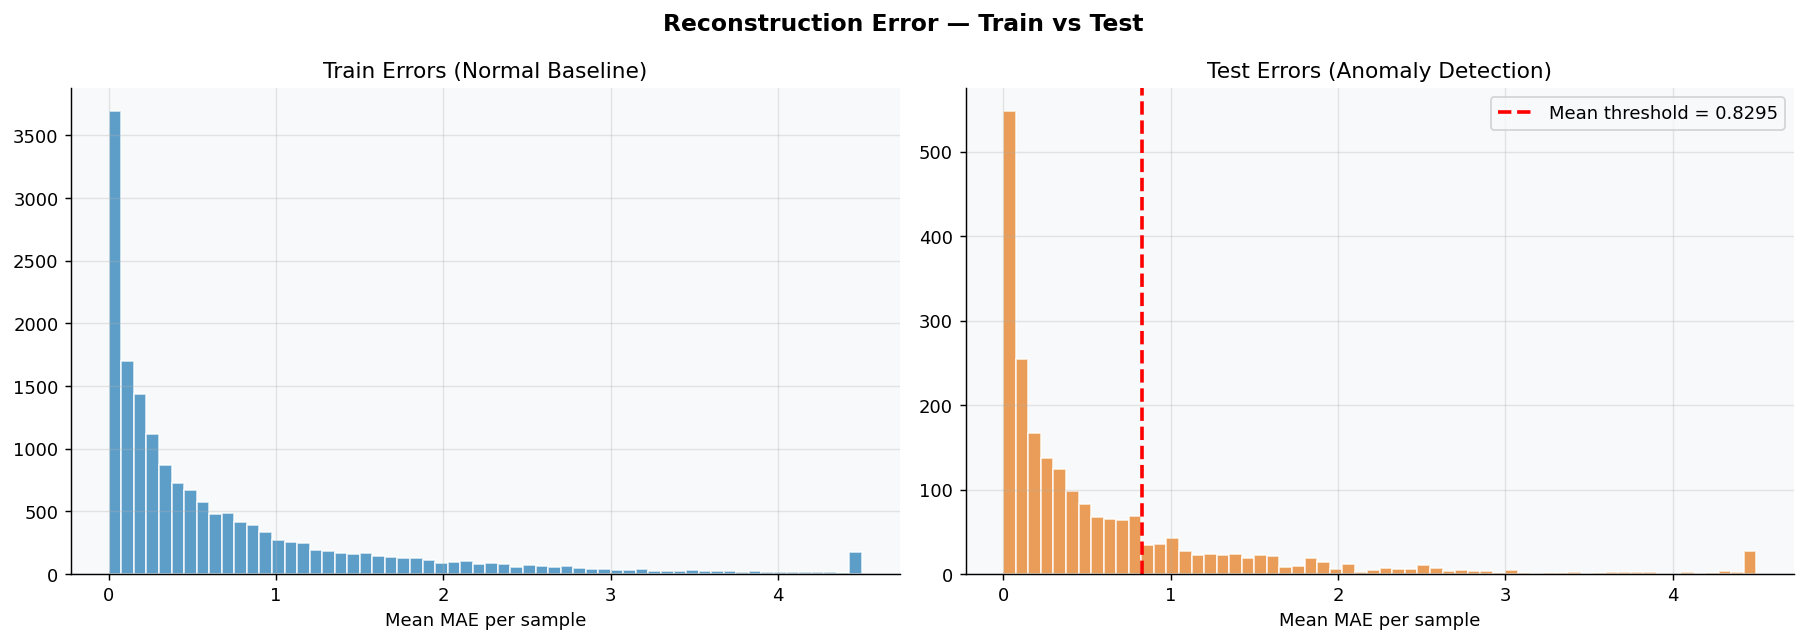

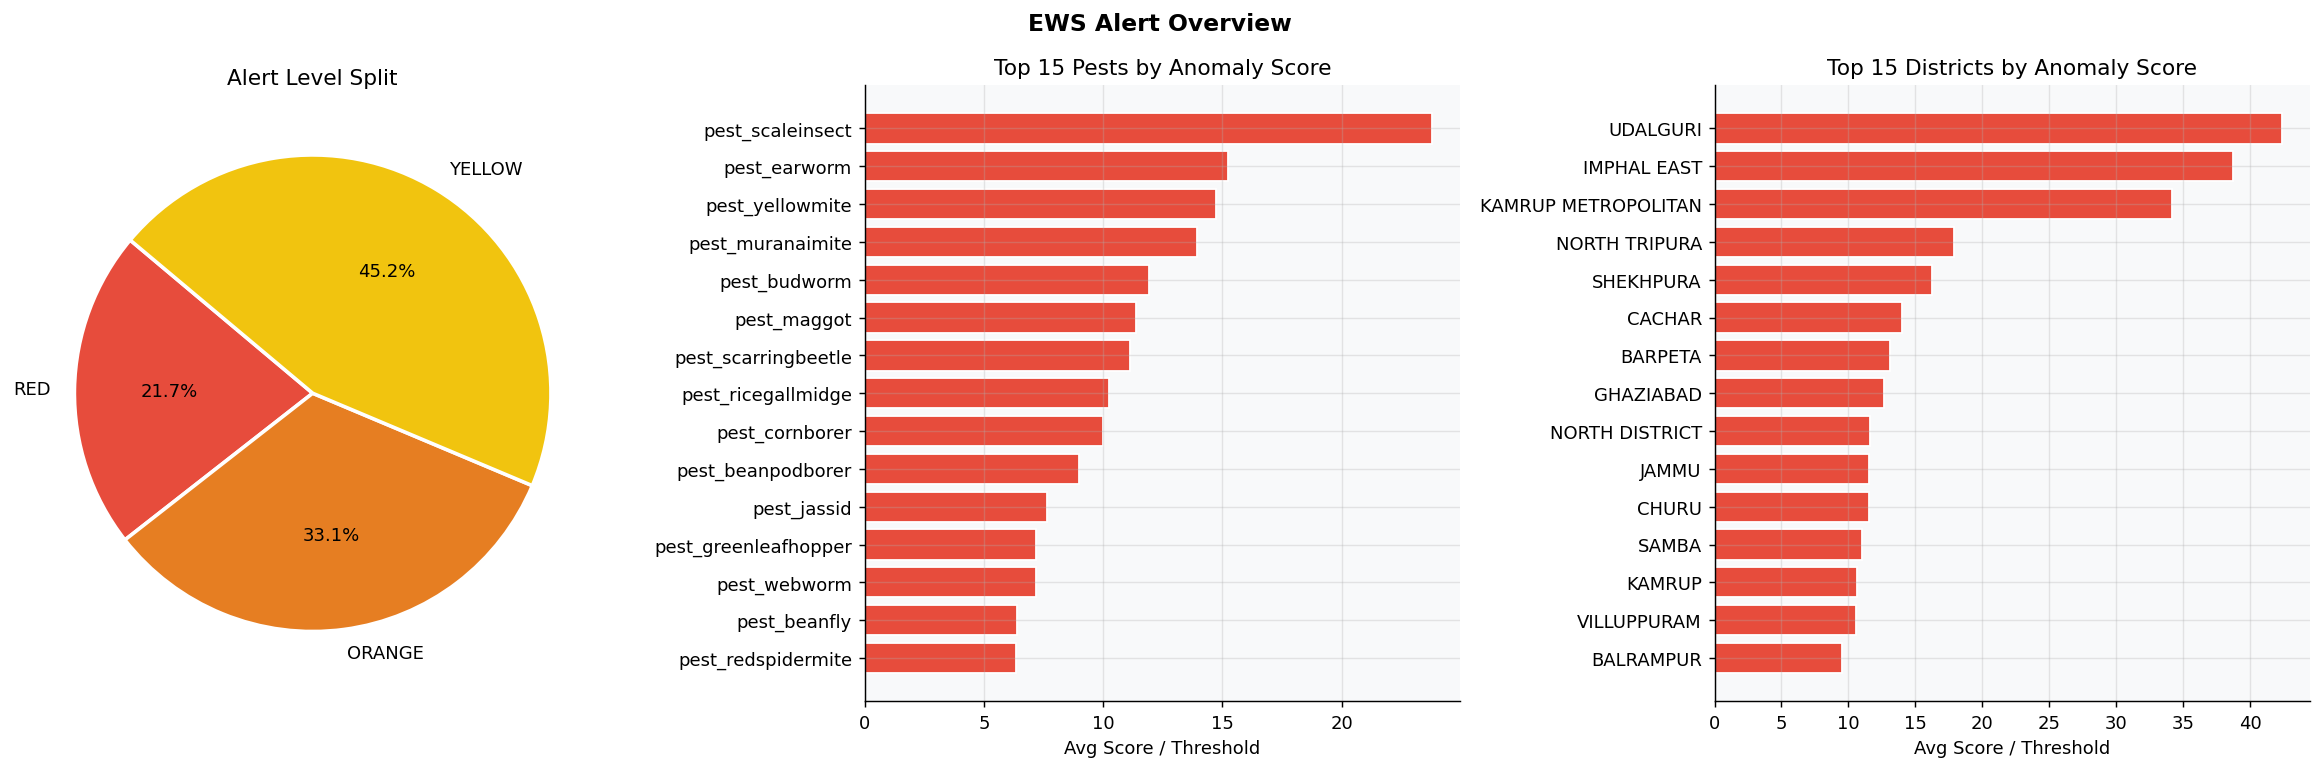

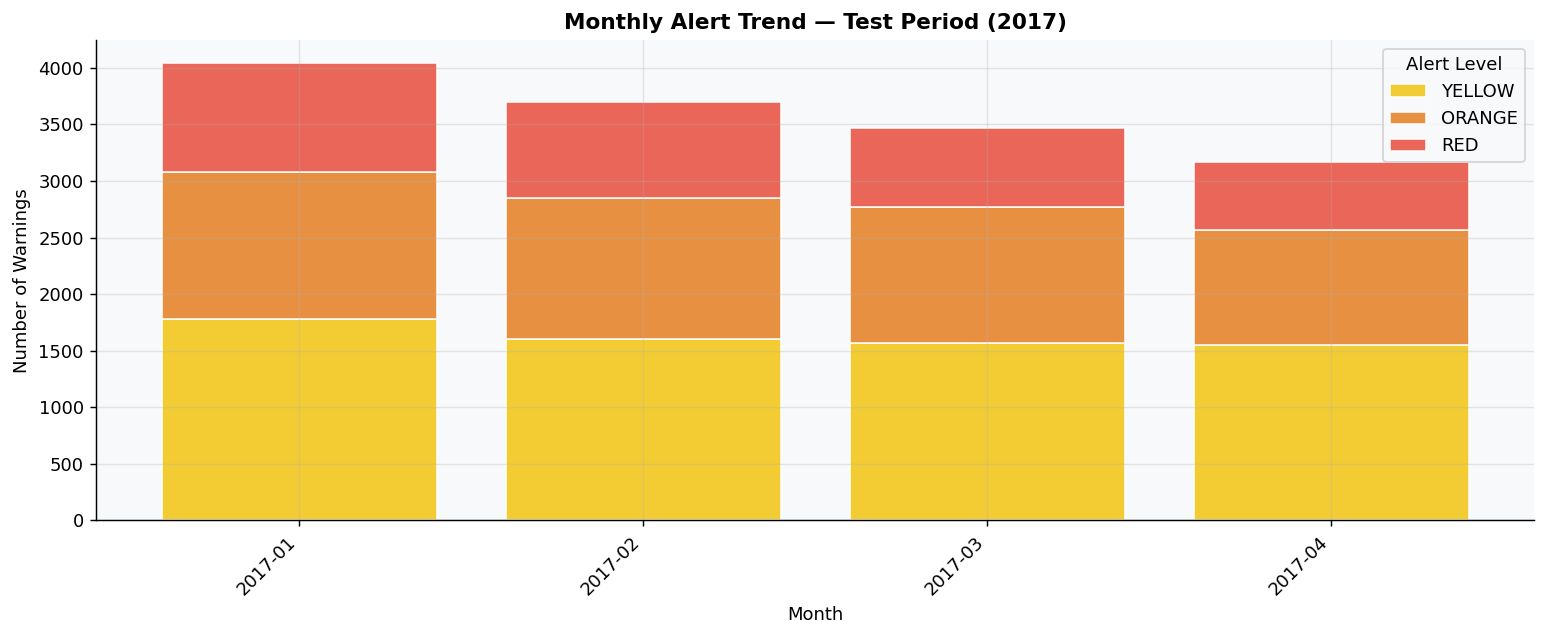

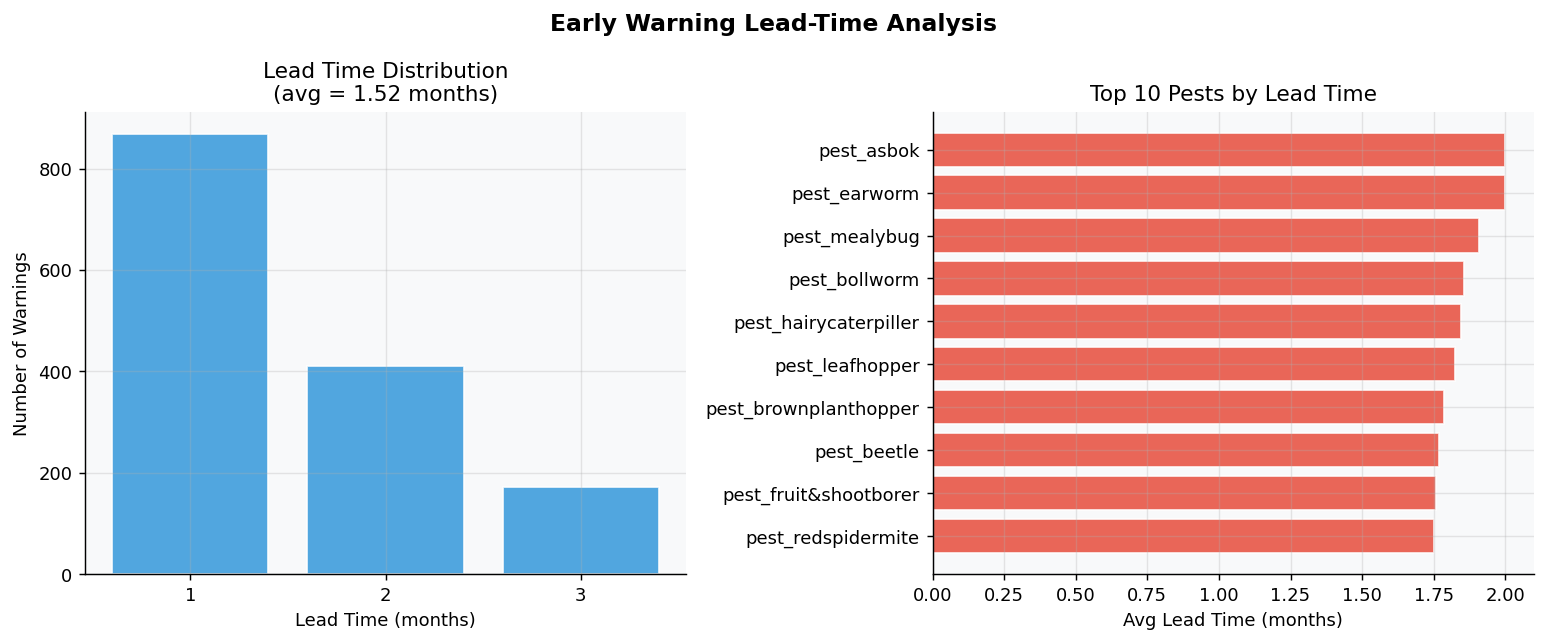

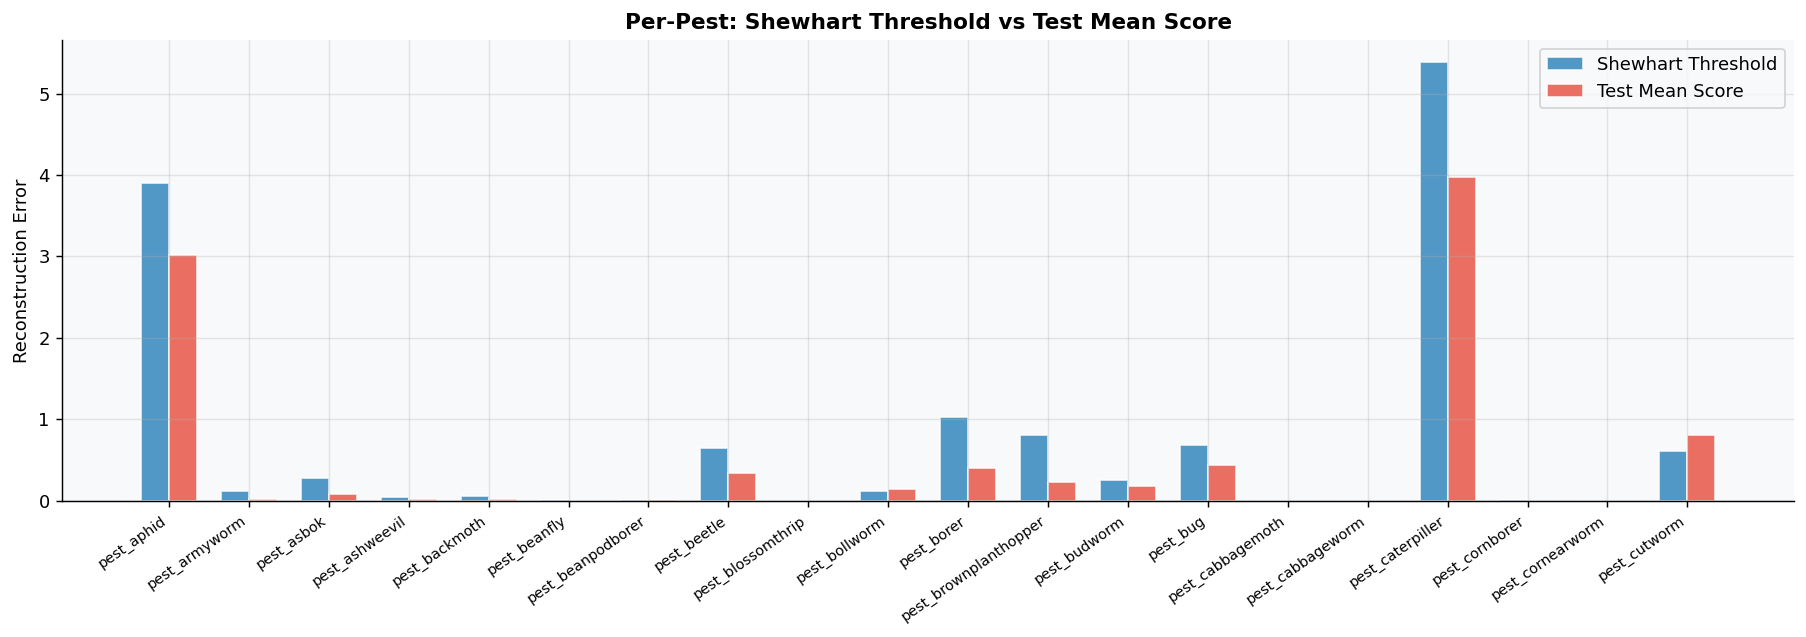

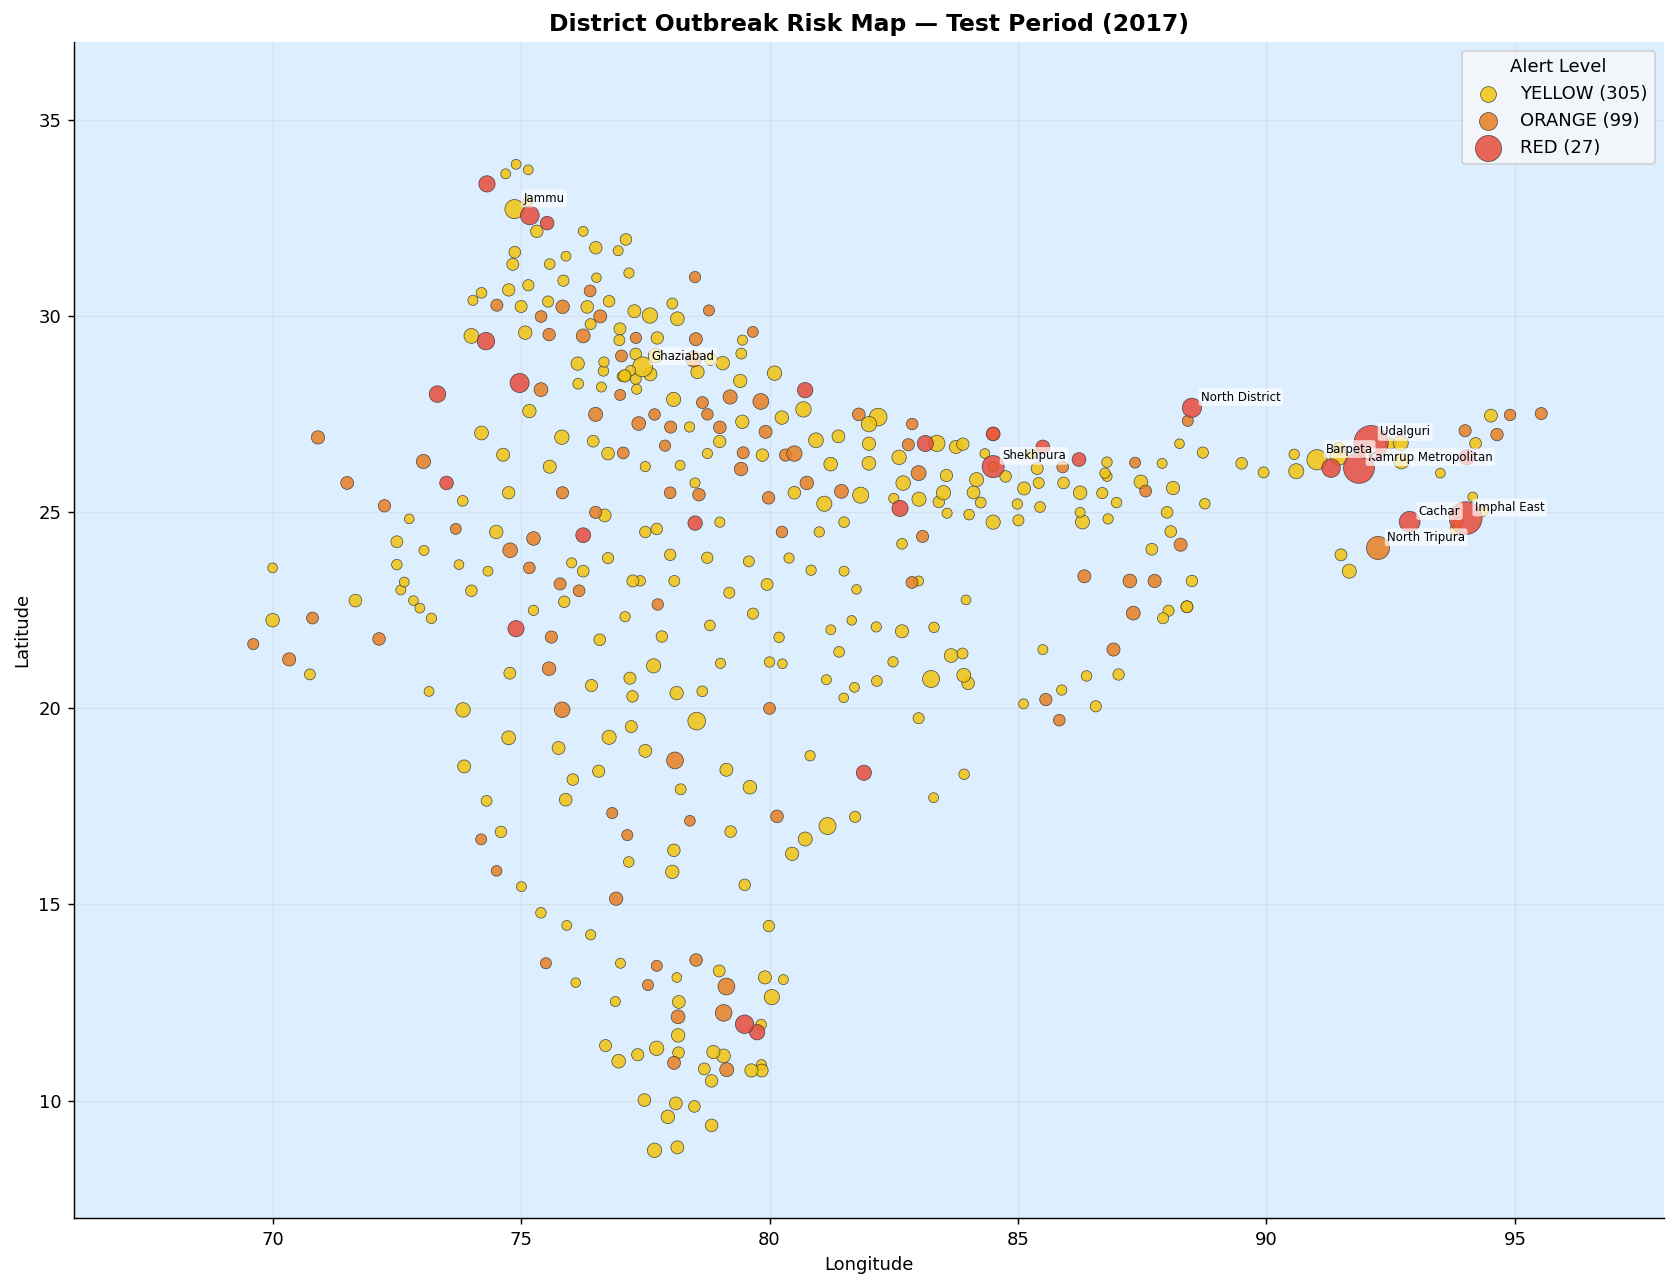


All 7 plots saved ✓


In [17]:
# ── Plot 2: Error distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Reconstruction Error — Train vs Test", fontsize=13, fontweight="bold")
mean_thresh = float(np.mean(list(thresholds.values())))

train_mean_err = train_errors.mean(axis=1)
test_mean_err  = test_errors.mean(axis=1)
clip_val = np.percentile(np.concatenate([train_mean_err, test_mean_err]), 99)

axes[0].hist(np.clip(train_mean_err, 0, clip_val), bins=60, color="#2980b9", alpha=0.75, edgecolor="white")
axes[0].set_title("Train Errors (Normal Baseline)"); axes[0].set_xlabel("Mean MAE per sample")
axes[1].hist(np.clip(test_mean_err,  0, clip_val), bins=60, color="#e67e22", alpha=0.75, edgecolor="white")
axes[1].axvline(mean_thresh, color="red", lw=2, linestyle="--",
                label=f"Mean threshold = {mean_thresh:.4f}")
axes[1].set_title("Test Errors (Anomaly Detection)"); axes[1].set_xlabel("Mean MAE per sample")
axes[1].legend()
plt.tight_layout()
plt.savefig("ews_ae_02_error_dist.png", dpi=150, bbox_inches="tight"); plt.show()

# ── Plot 3: Alert overview ────────────────────────────────────────────────────
if len(active) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("EWS Alert Overview", fontsize=13, fontweight="bold")

    ac = active["alert_level"].value_counts()
    lvls = [l for l in ["RED","ORANGE","YELLOW"] if l in ac.index]
    axes[0].pie([ac[l] for l in lvls], labels=lvls,
                colors=[ALERT_COLORS[l] for l in lvls],
                autopct="%1.1f%%", startangle=140,
                wedgeprops=dict(edgecolor="white", linewidth=2))
    axes[0].set_title("Alert Level Split")

    pest_sr = active.groupby("pest")["score_ratio"].mean().sort_values(ascending=False).head(15)
    axes[1].barh(pest_sr.index, pest_sr.values,
                 color=[ALERT_COLORS["RED"] if v>=5 else ALERT_COLORS["ORANGE"] if v>=2
                        else ALERT_COLORS["YELLOW"] for v in pest_sr.values], edgecolor="white")
    axes[1].set_xlabel("Avg Score / Threshold"); axes[1].set_title("Top 15 Pests by Anomaly Score")
    axes[1].invert_yaxis()

    dist_sr = active.groupby("district")["score_ratio"].mean().sort_values(ascending=False).head(15)
    axes[2].barh(dist_sr.index, dist_sr.values,
                 color=[ALERT_COLORS["RED"] if v>=5 else ALERT_COLORS["ORANGE"] if v>=2
                        else ALERT_COLORS["YELLOW"] for v in dist_sr.values], edgecolor="white")
    axes[2].set_xlabel("Avg Score / Threshold"); axes[2].set_title("Top 15 Districts by Anomaly Score")
    axes[2].invert_yaxis()
    plt.tight_layout()
    plt.savefig("ews_ae_03_alerts.png", dpi=150, bbox_inches="tight"); plt.show()

# ── Plot 4: Monthly alert trend ───────────────────────────────────────────────
if len(active) > 0:
    active["month_dt"] = pd.to_datetime(active["start_date"].str[:10], errors="coerce").dt.to_period("M")
    monthly = active.groupby(["month_dt","alert_level"]).size().unstack(fill_value=0)
    monthly.index = monthly.index.astype(str)

    fig, ax = plt.subplots(figsize=(12, 5))
    bottom = np.zeros(len(monthly))
    for lvl in ["YELLOW","ORANGE","RED"]:
        if lvl in monthly.columns:
            ax.bar(monthly.index, monthly[lvl], bottom=bottom,
                   color=ALERT_COLORS[lvl], label=lvl, alpha=0.85, edgecolor="white")
            bottom += monthly[lvl].values
    ax.set_xlabel("Month"); ax.set_ylabel("Number of Warnings")
    ax.set_title("Monthly Alert Trend — Test Period (2017)", fontweight="bold")
    ax.legend(title="Alert Level")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout()
    plt.savefig("ews_ae_04_monthly_trend.png", dpi=150, bbox_inches="tight"); plt.show()

# ── Plot 5: Lead-time distribution ────────────────────────────────────────────
if len(lead_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Early Warning Lead-Time Analysis", fontsize=13, fontweight="bold")

    lt_counts = lead_df["lead_months"].value_counts().sort_index()
    axes[0].bar(lt_counts.index, lt_counts.values, color="#3498db", edgecolor="white", alpha=0.85)
    axes[0].set_xlabel("Lead Time (months)"); axes[0].set_ylabel("Number of Warnings")
    axes[0].set_title(f"Lead Time Distribution\n(avg = {lead_df['lead_months'].mean():.2f} months)")
    axes[0].set_xticks(lt_counts.index)

    top_pests_lt = lead_df.groupby("pest")["lead_months"].mean().sort_values(ascending=False).head(10)
    axes[1].barh(top_pests_lt.index, top_pests_lt.values, color="#e74c3c", edgecolor="white", alpha=0.85)
    axes[1].set_xlabel("Avg Lead Time (months)"); axes[1].set_title("Top 10 Pests by Lead Time")
    axes[1].invert_yaxis()
    plt.tight_layout()
    plt.savefig("ews_ae_05_lead_time.png", dpi=150, bbox_inches="tight"); plt.show()

# ── Plot 6: Per-pest threshold vs test score ──────────────────────────────────
n_p = min(20, len(pest_names))
pp  = pest_names[:n_p]
x   = np.arange(n_p); w = 0.35
tv  = [thresholds.get(p, 0) for p in pp]
tms = [test_scores[p].mean() if p in test_scores.columns else 0 for p in pp]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x-w/2, tv,  w, label="Shewhart Threshold", color="#2980b9", alpha=0.8, edgecolor="white")
ax.bar(x+w/2, tms, w, label="Test Mean Score",     color="#e74c3c", alpha=0.8, edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(pp, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Reconstruction Error")
ax.set_title("Per-Pest: Shewhart Threshold vs Test Mean Score", fontweight="bold")
ax.legend(); plt.tight_layout()
plt.savefig("ews_ae_06_threshold_vs_test.png", dpi=150, bbox_inches="tight"); plt.show()

# ── Plot 7: District risk map ─────────────────────────────────────────────────
if len(active) > 0 and config.data.latitude_column in wide.columns:
    coords = wide.groupby(config.data.district_column)[
        [config.data.latitude_column, config.data.longitude_column]
    ].mean().reset_index()
    coords.columns = ["district","lat","lon"]

    dist_risk = (active.groupby("district")
                 .agg(score_ratio=("score_ratio","mean"),
                      alert_level=("alert_level", lambda x: x.value_counts().index[0]),
                      n_alerts   =("pest","count"))
                 .reset_index()
                 .merge(coords, on="district", how="left")
                 .dropna(subset=["lat","lon"]))

    fig, ax = plt.subplots(figsize=(13, 10))
    ax.set_facecolor("#ddeeff")
    for lvl in ["YELLOW","ORANGE","RED"]:
        sub   = dist_risk[dist_risk["alert_level"]==lvl]
        sizes = np.clip(sub["score_ratio"] * 8 + 20, 20, 400)
        ax.scatter(sub["lon"], sub["lat"], c=ALERT_COLORS[lvl], s=sizes,
                   label=f"{lvl} ({len(sub)})", alpha=0.85,
                   edgecolors="#333", linewidths=0.4, zorder=3)
    for _, row in dist_risk.nlargest(10, "score_ratio").iterrows():
        ax.annotate(row["district"].title(), xy=(row["lon"], row["lat"]),
                    xytext=(5,4), textcoords="offset points", fontsize=6.5,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))
    ax.set_xlim(66,98); ax.set_ylim(7,37)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title("District Outbreak Risk Map — Test Period (2017)",
                 fontsize=13, fontweight="bold")
    ax.legend(title="Alert Level", fontsize=10); ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig("ews_ae_07_map.png", dpi=150, bbox_inches="tight"); plt.show()

print("\nAll 7 plots saved ✓")

## Cell 17 — Save Outputs & Final Summary

## Cell 16 — Extra Visualisations
5 additional plots: seasonal heatmap, detection donut, per-pest breakdown, district persistence heatmap, anomaly score violin.

Plotting Viz A: Seasonal heatmap ...


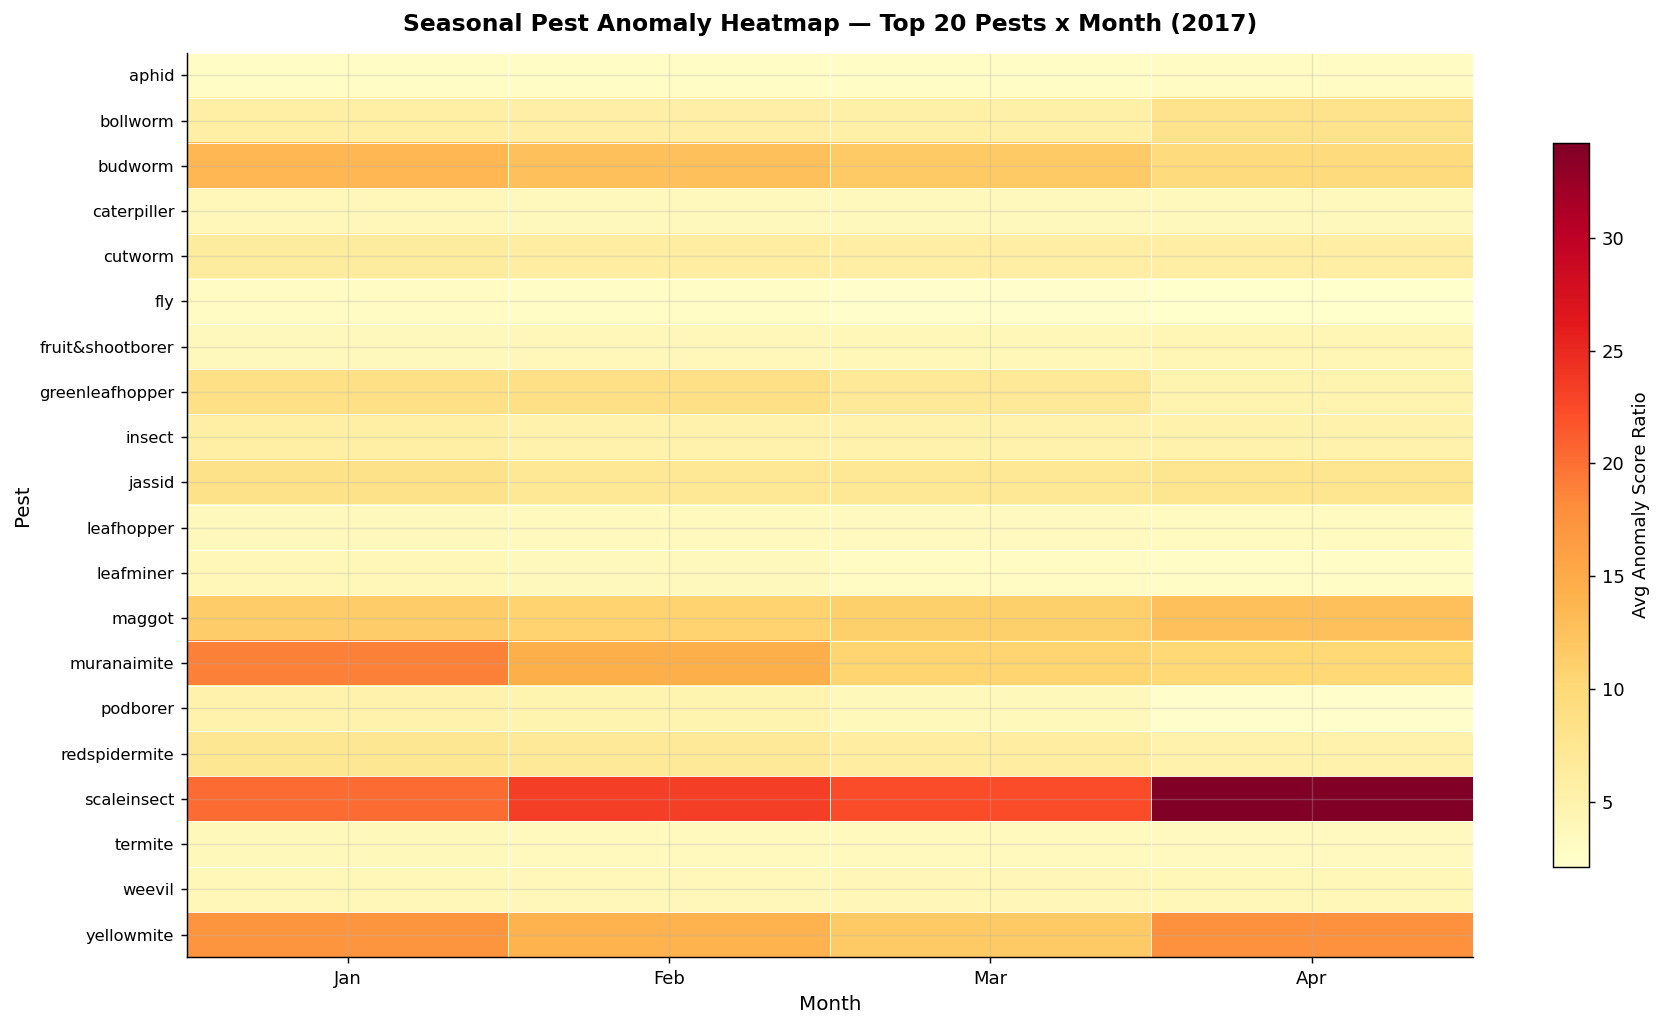

  Saved: ews_ae_08_seasonal_heatmap.png
Plotting Viz B: Detection rate donut ...


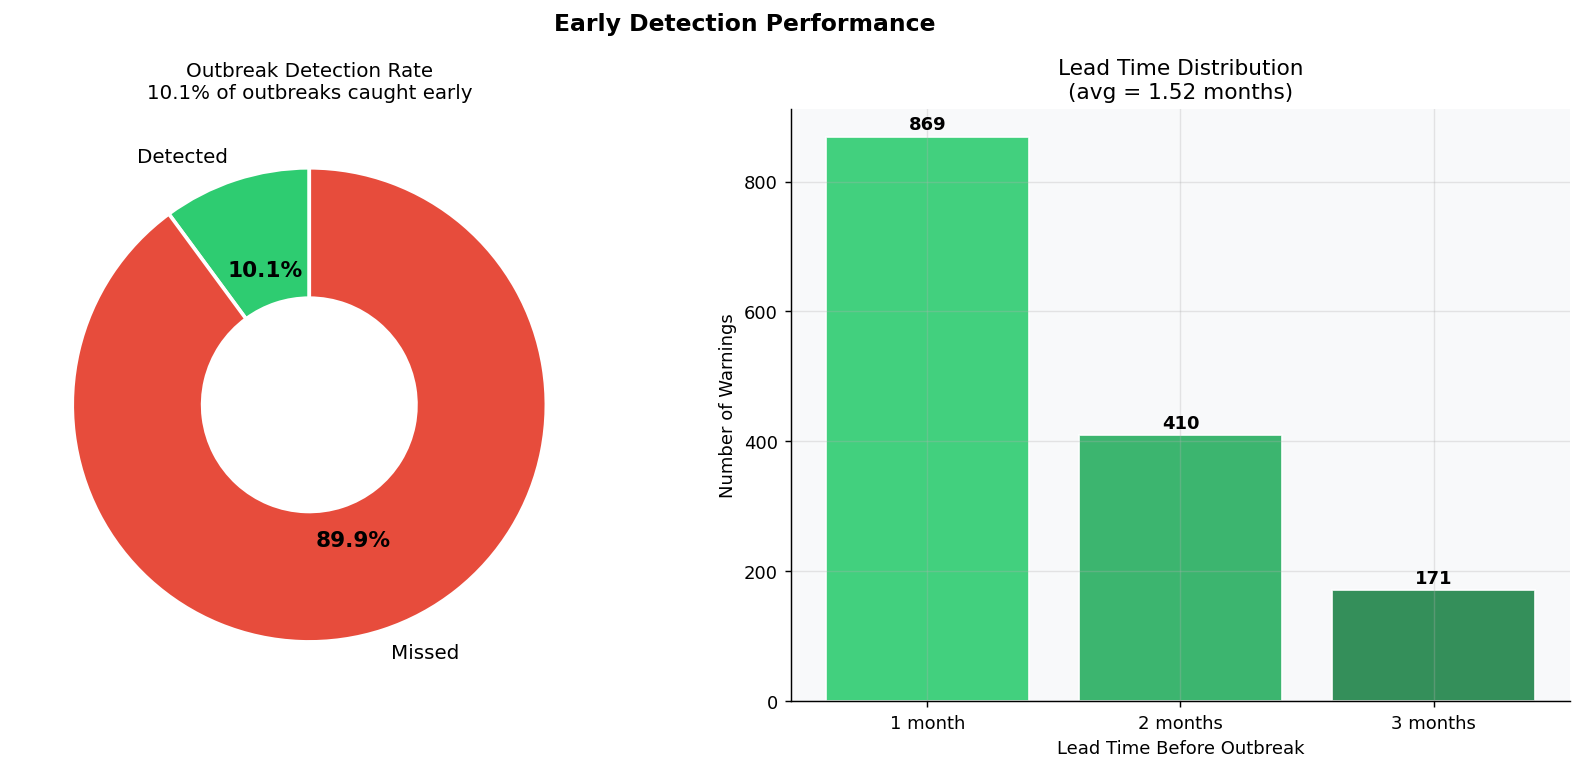

  Detection rate: 10.1%
  Saved: ews_ae_09_detection_donut.png
Plotting Viz C: Per-pest alert breakdown ...


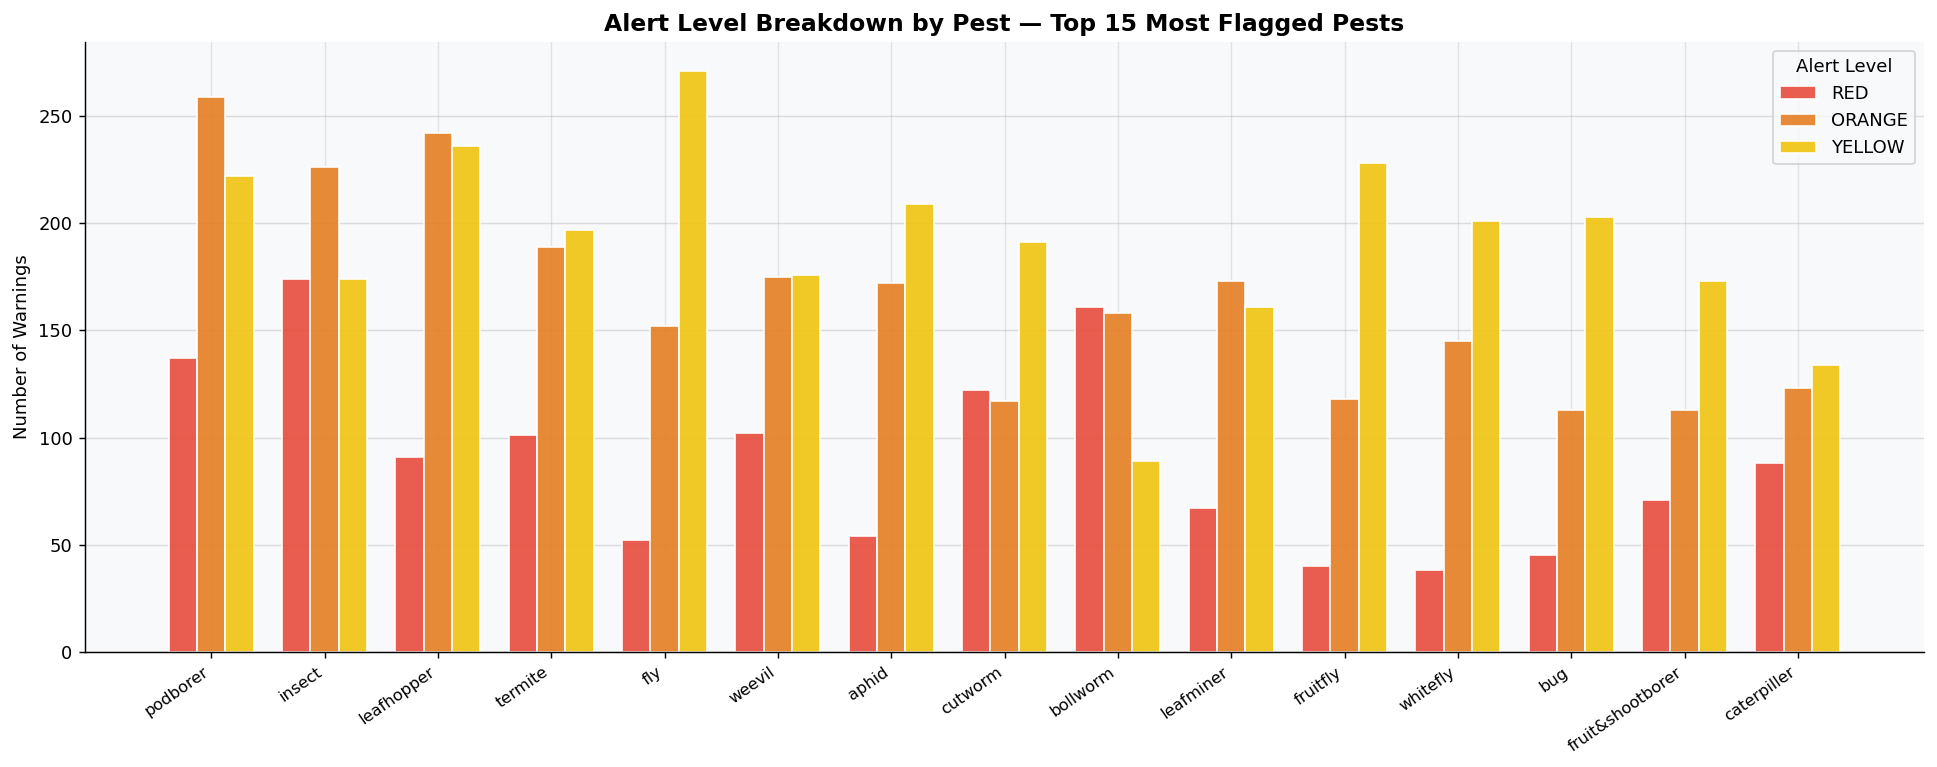

  Saved: ews_ae_10_pest_breakdown.png
Plotting Viz D: District persistence heatmap ...


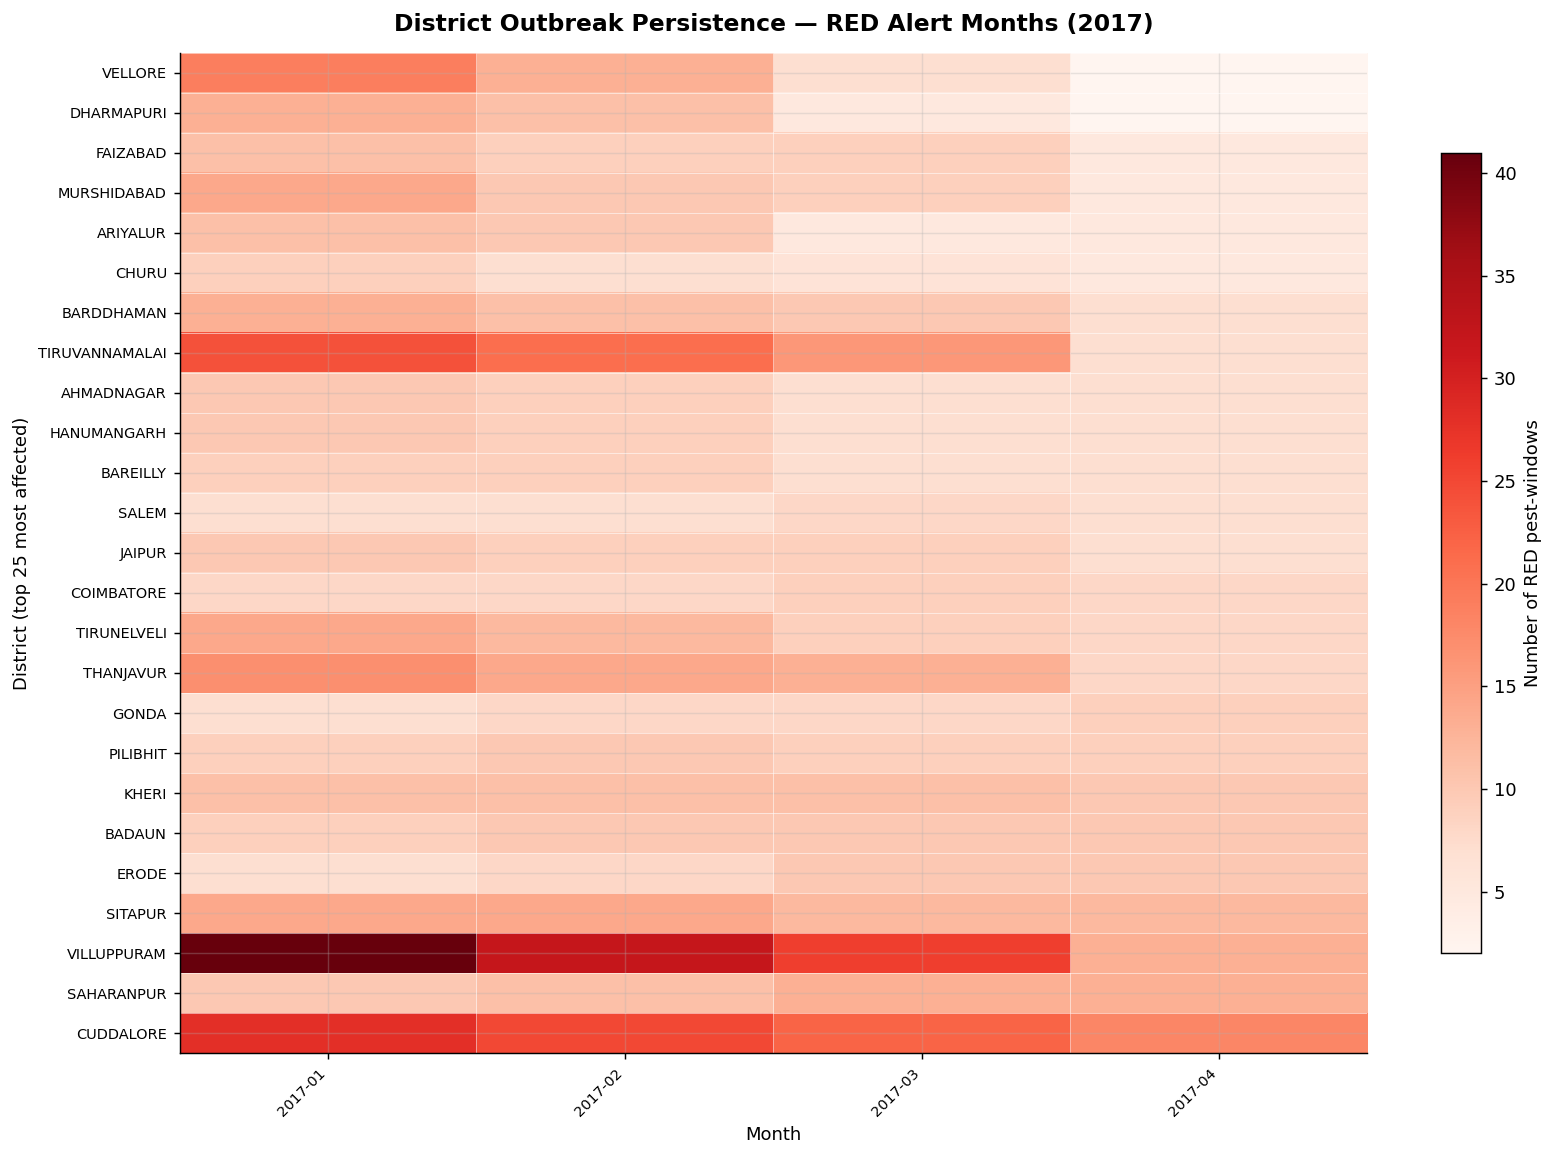

  Saved: ews_ae_11_district_persistence.png
Plotting Viz E: Score ratio violin plot ...


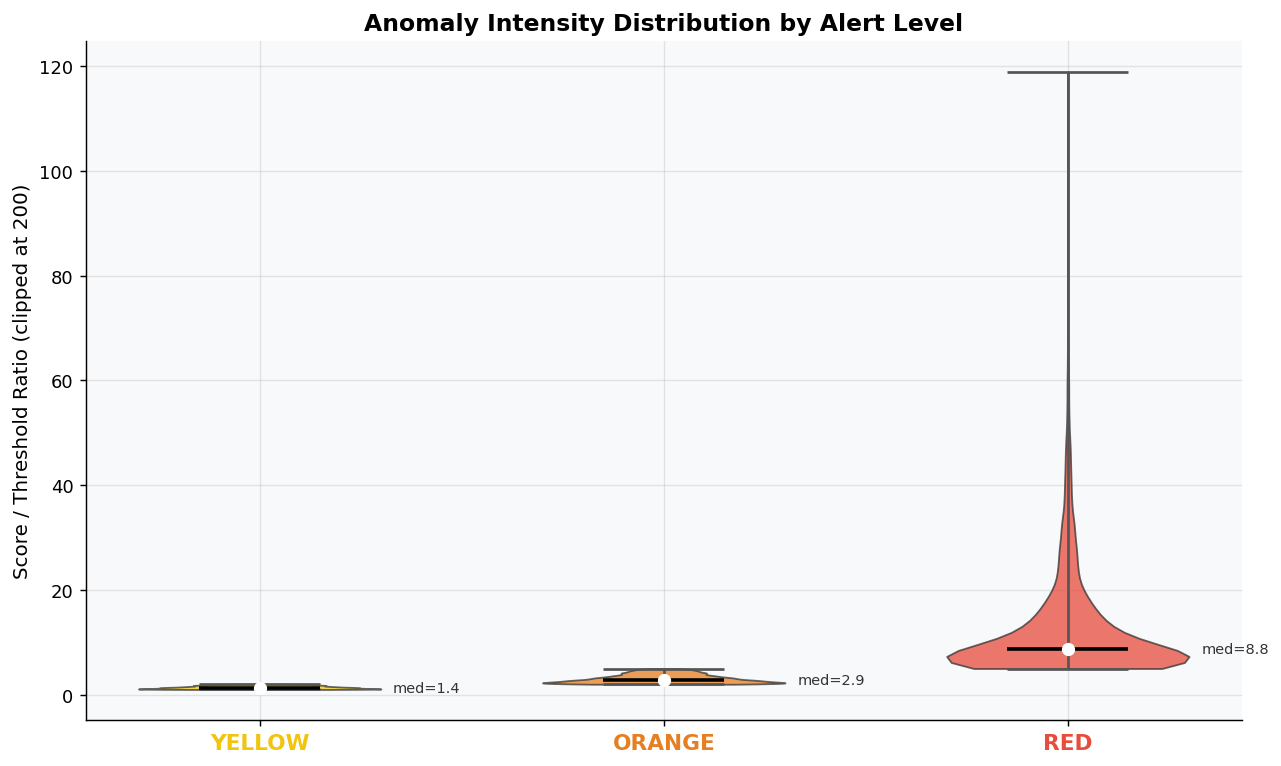

  Saved: ews_ae_12_score_violin.png

✅ All 5 extra visualisations done!
  ews_ae_08_seasonal_heatmap.png
  ews_ae_09_detection_donut.png
  ews_ae_10_pest_breakdown.png
  ews_ae_11_district_persistence.png
  ews_ae_12_score_violin.png


In [18]:
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ═══════════════════════════════════════════════════════════════════
#  EXTRA VISUALISATIONS  (run after Cell 14)
# ═══════════════════════════════════════════════════════════════════

# ── VIZ A: Seasonal Heatmap — pest × month alert intensity ────────
print("Plotting Viz A: Seasonal heatmap ...")

active["month_num"]  = pd.to_datetime(active["start_date"].str[:10], errors="coerce").dt.month
active["month_name"] = pd.to_datetime(active["start_date"].str[:10], errors="coerce").dt.strftime("%b")

heatmap_data = (active.groupby(["pest","month_num"])["score_ratio"]
                .mean().unstack(fill_value=0))
heatmap_data.columns = [pd.Timestamp(2017, m, 1).strftime("%b") for m in heatmap_data.columns]

top20 = active.groupby("pest")["score_ratio"].sum().nlargest(20).index
heatmap_data = heatmap_data.loc[heatmap_data.index.isin(top20)]
heatmap_data.index = heatmap_data.index.str.replace("pest_", "")

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="YlOrRd", interpolation="nearest")
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, fontsize=10)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)
plt.colorbar(im, ax=ax, label="Avg Anomaly Score Ratio", shrink=0.8)
ax.set_title("Seasonal Pest Anomaly Heatmap — Top 20 Pests x Month (2017)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Pest", fontsize=11)
for i in range(len(heatmap_data.index)+1):
    ax.axhline(i-0.5, color="white", lw=0.5)
for j in range(len(heatmap_data.columns)+1):
    ax.axvline(j-0.5, color="white", lw=0.5)
plt.tight_layout()
plt.savefig("ews_ae_08_seasonal_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: ews_ae_08_seasonal_heatmap.png")


# ── VIZ B: Detection rate donut + lead time bar ───────────────────
print("Plotting Viz B: Detection rate donut ...")

if len(lead_df) > 0:
    outbreak_pairs     = set(zip(lead_df["district"], lead_df["pest"]))
    gt_outbreak_pairs  = set(zip(gt[gt["outbreak"]]["district"], gt[gt["outbreak"]]["pest"]))
    detected  = len(outbreak_pairs & gt_outbreak_pairs)
    missed    = len(gt_outbreak_pairs) - detected
    det_rate  = detected / max(len(gt_outbreak_pairs), 1) * 100

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    fig.suptitle("Early Detection Performance", fontsize=13, fontweight="bold")

    sizes  = [detected, missed]
    colors = ["#2ecc71", "#e74c3c"]
    wedges, texts, autotexts = axes[0].pie(
        sizes, labels=["Detected","Missed"], colors=colors,
        autopct="%1.1f%%", startangle=90,
        wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
        textprops=dict(fontsize=11))
    for at in autotexts:
        at.set_fontsize(12); at.set_fontweight("bold")
    axes[0].set_title(f"Outbreak Detection Rate\n{det_rate:.1f}% of outbreaks caught early",
                      fontsize=11)

    lt_counts  = lead_df["lead_months"].value_counts().sort_index()
    bar_colors = ["#2ecc71","#27ae60","#1e8449","#145a32"][:len(lt_counts)]
    bars = axes[1].bar(
        lt_counts.index.astype(str).map(lambda x: f"{x} month{'s' if int(x)>1 else ''}"),
        lt_counts.values, color=bar_colors, edgecolor="white", alpha=0.9)
    for bar, val in zip(bars, lt_counts.values):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                     str(val), ha="center", va="bottom", fontsize=10, fontweight="bold")
    axes[1].set_xlabel("Lead Time Before Outbreak")
    axes[1].set_ylabel("Number of Warnings")
    axes[1].set_title(f"Lead Time Distribution\n(avg = {lead_df['lead_months'].mean():.2f} months)")

    plt.tight_layout()
    plt.savefig("ews_ae_09_detection_donut.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Detection rate: {det_rate:.1f}%")
    print("  Saved: ews_ae_09_detection_donut.png")
else:
    print("  Skipped — no lead_df")


# ── VIZ C: Per-pest grouped bar — RED vs ORANGE vs YELLOW ─────────
print("Plotting Viz C: Per-pest alert breakdown ...")

pest_alert = (active.groupby(["pest","alert_level"])
              .size().unstack(fill_value=0)
              .assign(total=lambda d: d.sum(axis=1))
              .sort_values("total", ascending=False)
              .head(15)
              .drop(columns=["total"]))
pest_alert.index = pest_alert.index.str.replace("pest_","")

lvl_order = [l for l in ["RED","ORANGE","YELLOW"] if l in pest_alert.columns]
x = np.arange(len(pest_alert))
w = 0.25
fig, ax = plt.subplots(figsize=(15, 6))
for i, lvl in enumerate(lvl_order):
    offset = (i - len(lvl_order)/2 + 0.5) * w
    ax.bar(x + offset, pest_alert[lvl], w,
           label=lvl, color=ALERT_COLORS[lvl], edgecolor="white", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(pest_alert.index, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Number of Warnings")
ax.set_title("Alert Level Breakdown by Pest — Top 15 Most Flagged Pests",
             fontsize=13, fontweight="bold")
ax.legend(title="Alert Level", fontsize=10)
ax.yaxis.grid(True, alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("ews_ae_10_pest_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: ews_ae_10_pest_breakdown.png")


# ── VIZ D: District persistence heatmap — RED alert months ────────
print("Plotting Viz D: District persistence heatmap ...")

red_alerts = active[active["alert_level"]=="RED"].copy()
if len(red_alerts) > 0:
    red_alerts["month_str"] = pd.to_datetime(
        red_alerts["start_date"].str[:10], errors="coerce").dt.strftime("%Y-%m")
    pers  = (red_alerts.groupby(["district","month_str"])
             .size().unstack(fill_value=0))
    top25 = pers.sum(axis=1).nlargest(25).index
    pers  = pers.loc[top25].sort_values(by=pers.columns[-1], ascending=True)

    fig, ax = plt.subplots(figsize=(13, 9))
    im = ax.imshow(pers.values, aspect="auto", cmap="Reds", interpolation="nearest")
    ax.set_xticks(range(len(pers.columns)))
    ax.set_xticklabels(pers.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(pers.index)))
    ax.set_yticklabels(pers.index, fontsize=8)
    plt.colorbar(im, ax=ax, label="Number of RED pest-windows", shrink=0.8)
    ax.set_title("District Outbreak Persistence — RED Alert Months (2017)",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Month", fontsize=10)
    ax.set_ylabel("District (top 25 most affected)", fontsize=10)
    for i in range(len(pers.index)+1):
        ax.axhline(i-0.5, color="white", lw=0.3)
    for j in range(len(pers.columns)+1):
        ax.axvline(j-0.5, color="white", lw=0.3)
    plt.tight_layout()
    plt.savefig("ews_ae_11_district_persistence.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved: ews_ae_11_district_persistence.png")
else:
    print("  No RED alerts to plot")


# ── VIZ E: Score ratio violin — anomaly intensity per alert level ─
print("Plotting Viz E: Score ratio violin plot ...")

fig, ax = plt.subplots(figsize=(10, 6))
lvl_order_v = [l for l in ["YELLOW","ORANGE","RED"] if l in active["alert_level"].values]
data_v = [active[active["alert_level"]==l]["score_ratio"].clip(upper=200).values
          for l in lvl_order_v]

parts = ax.violinplot(data_v, positions=range(len(lvl_order_v)),
                      showmedians=True, showextrema=True, widths=0.6)
for pc, lvl in zip(parts["bodies"], lvl_order_v):
    pc.set_facecolor(ALERT_COLORS[lvl]); pc.set_alpha(0.75); pc.set_edgecolor("#333")
parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(2)
parts["cmaxes"].set_color("#555");   parts["cmins"].set_color("#555")
parts["cbars"].set_color("#555")

for i, (d, lvl) in enumerate(zip(data_v, lvl_order_v)):
    med = np.median(d)
    ax.scatter([i], [med], color="white", s=40, zorder=3)
    ax.text(i+0.33, med, f"med={med:.1f}", va="center", fontsize=8, color="#333")

ax.set_xticks(range(len(lvl_order_v)))
ax.set_xticklabels(lvl_order_v, fontsize=12, fontweight="bold")
for tick, lvl in zip(ax.get_xticklabels(), lvl_order_v):
    tick.set_color(ALERT_COLORS[lvl])
ax.set_ylabel("Score / Threshold Ratio (clipped at 200)", fontsize=11)
ax.set_title("Anomaly Intensity Distribution by Alert Level",
             fontsize=13, fontweight="bold")
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("ews_ae_12_score_violin.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: ews_ae_12_score_violin.png")

print("\n✅ All 5 extra visualisations done!")
print("  ews_ae_08_seasonal_heatmap.png")
print("  ews_ae_09_detection_donut.png")
print("  ews_ae_10_pest_breakdown.png")
print("  ews_ae_11_district_persistence.png")
print("  ews_ae_12_score_violin.png")

In [19]:
import os

# Save CSVs
alerts_df.to_csv("ews_ae_alerts_full.csv", index=False)
print("Saved: ews_ae_alerts_full.csv")

if len(active):
    active.to_csv("ews_ae_active_warnings.csv", index=False)
    print(f"Saved: ews_ae_active_warnings.csv  ({len(active)} rows)")

first_det = get_first_detection_dates(alerts_df)
if len(first_det):
    first_det.to_csv("ews_ae_first_detections.csv", index=False)
    print("Saved: ews_ae_first_detections.csv")

thresh_df.to_csv("ews_ae_thresholds.csv", index=False)
print("Saved: ews_ae_thresholds.csv")

if len(lead_df):
    lead_df.to_csv("ews_ae_lead_time.csv", index=False)
    print(f"Saved: ews_ae_lead_time.csv  ({len(lead_df)} rows)")

# Save model
os.makedirs("./ews_checkpoints", exist_ok=True)
torch.save(model.state_dict(), "./ews_checkpoints/ews_model_final.pt")
print("Saved: ews_checkpoints/ews_model_final.pt")

# Final summary
ac2 = active["alert_level"].value_counts() if len(active) else {}
print("\n" + "="*55)
print("  PEST EWS — FINAL SUMMARY")
print("="*55)
print(f"  Architecture  : Conv3DEncoder → ConvLSTMEncoder → Decoder")
print(f"  Model params  : {sum(p.numel() for p in model.parameters()):,}")
print(f"  Best epoch    : {history['best_epoch']} / {config.model.epochs}")
print(f"  Best val loss : {history['best_val_loss']:.6f}")
print(f"  Districts     : {len(valid_districts)}")
print(f"  Pests         : {len(pest_names)}")
print(f"  Test samples  : {len(alerts_df):,}")
print(f"  Active alerts : {len(active):,}  ({len(active)/max(len(alerts_df),1)*100:.1f}%)")
for lvl in ["RED","ORANGE","YELLOW"]:
    print(f"    {lvl:7s}     : {ac2.get(lvl,0):,}")
if len(lead_df):
    print(f"  Avg lead time : {lead_df['lead_months'].mean():.2f} months")
    print(f"  Leads found   : {len(lead_df):,}")
print("="*55)

Saved: ews_ae_alerts_full.csv
Saved: ews_ae_active_warnings.csv  (14378 rows)
Saved: ews_ae_first_detections.csv
Saved: ews_ae_thresholds.csv
Saved: ews_ae_lead_time.csv  (1450 rows)
Saved: ews_checkpoints/ews_model_final.pt

  PEST EWS — FINAL SUMMARY
  Architecture  : Conv3DEncoder → ConvLSTMEncoder → Decoder
  Model params  : 1,112,719
  Best epoch    : 82 / 100
  Best val loss : 0.701421
  Districts     : 542
  Pests         : 63
  Test samples  : 136,584
  Active alerts : 14,378  (10.5%)
    RED         : 3,115
    ORANGE      : 4,760
    YELLOW      : 6,503
  Avg lead time : 1.52 months
  Leads found   : 1,450
